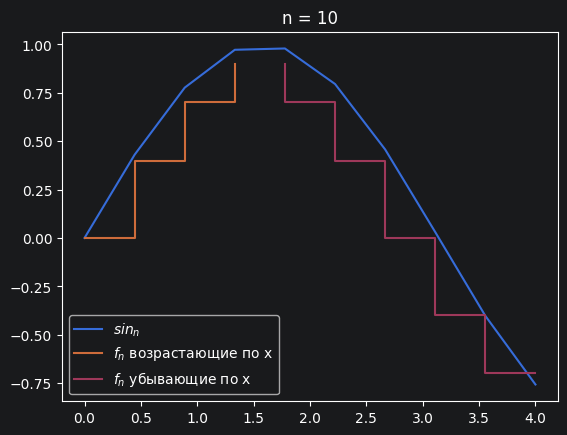

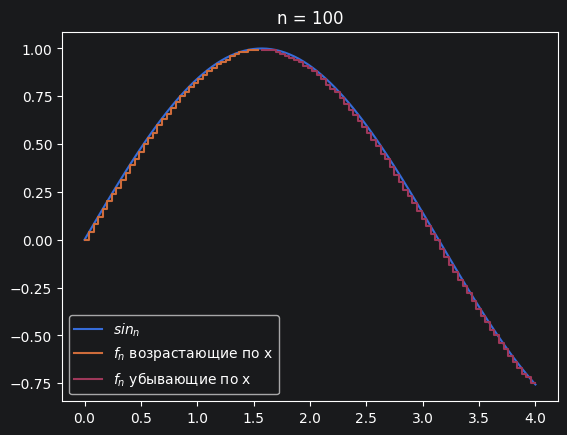

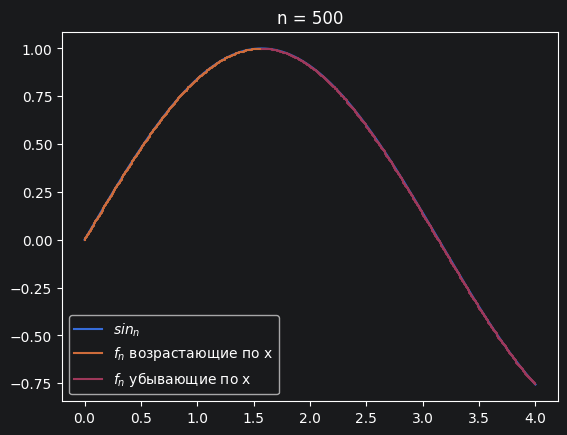

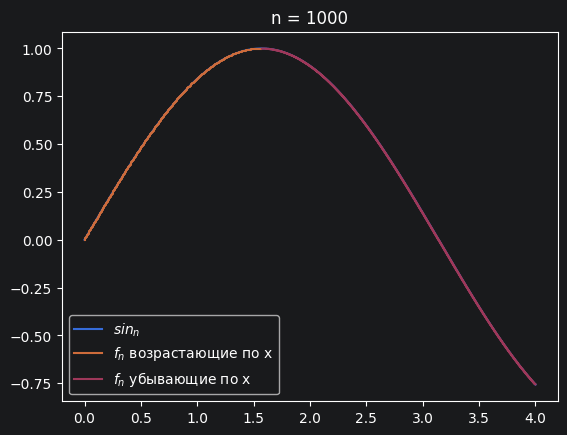

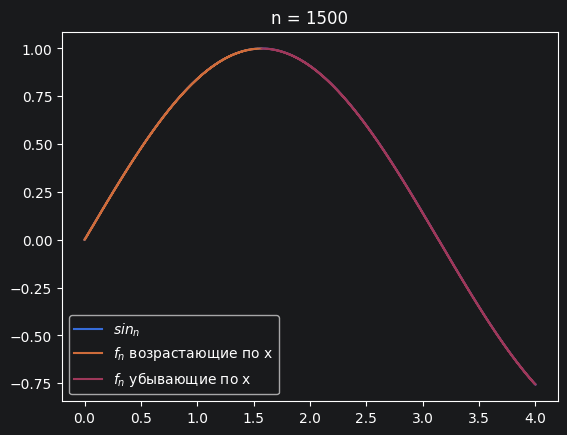

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Последовательность f_n
def f_n(x):
    summa = 0
    for (a, b), val in A:
        summa += val * ((a <= x) & (x < b))    # i/n * indicator(A_i)
    return np.sign(np.sin(x)) * summa

# Интеграл Лебега-Стилтьеса
def lebesgue_integral():
    summa = 0
    for x_i in range(0, n - 1):
        summa += f_n(E[x_i]) * (E[x_i + 1] - E[x_i])    # f(x) * (x_{i + 1} - x_{i})
    return summa

# Интеграл Лебега-Стилтьеса
def lebesgue_stieltjes_integral():
    summa = 0
    for x_i in range(0, n - 1):
        summa += f_n(E[x_i]) * (np.floor(E[x_i + 1]) - np.floor(E[x_i]))    # f(x) * (floor(x_{i + 1}) - floor(x_{i}))
    return summa

N = [10, 100, 500, 1000, 1500]

for n in N:
    E = np.linspace(0, 4, n)
    E_inc = E[E <= np.pi / 2]   # Возрастающая часть
    E_dec = E[E >= np.pi / 2]   # Убывающая часть

    # A_i - прообразы delta_i
    A = []

    delta = np.divide(1, n)    # delta = 1 / n
    for i in range(n):
        x_1 = i * delta    # i / n
        x_2 = (i + 1) * delta    # (i + 1) / n

        # Задаю A_i
        for k in range(2):
            A.append(((np.arcsin(x_1) + np.pi*k, np.arcsin(x_2) + np.pi*k), x_1))   # Возрастающая часть
            A.append(((np.pi - np.arcsin(x_2) + np.pi*k, np.pi - np.arcsin(x_1) + np.pi*k), x_1))   # Убывающая часть

    Y = f_n(E)

    # Строим графики:
    plt.figure()    # Создать для каждого графика отдельный плот
    plt.title(f"n = {n}")   # Название плота
    plt.plot(E, np.sin(E), label="$sin_n$")   # График синуса
    plt.step(E_inc, f_n(E_inc), where='post', label='$f_n$ возрастающие по x')   # График убывающей части
    plt.step(E_dec, f_n(E_dec), where='pre', label='$f_n$ убывающие по x')   # График возрастающей части
    plt.legend()    # Показать легенду

In [87]:
# Вычисляем интеграл Лебега для каждого n
for n in N:
    l_int = lebesgue_integral()
    print(l_int)

0.0002561707805203469
0.034262841894596406
0.7613093173226597
1.8874289526350887
1.6539310651545462


In [88]:
# Вычисляем интеграл Лебега-Стилтьеса для каждого n
for n in N:
    ls_int = lebesgue_stieltjes_integral()
    print(ls_int)

0.0
0.0
0.84
1.7493333333333334
1.1360000000000001
